# Bank Marketing Campaign — XGBoost Modelling

รวมสิ่งที่แก้ไป
- เอา Logis, RF มารวมเพื่อทำ all model perf (แก้ตัวแปรให้ชื่อไม่ชนกัน เช่น lg_model, rf_model แล้ว แต่ xg ขอไม่แก้ ขี้เกียจ)
- All model perf
- ลบ threshold optim : ทำไปก็เพิ่ม f1 มานิดเดียว ไม่คุ้ม ไม่เอา ไม่ทำ
- gain lift chart
- final summary (gain lift version marketing เข้าใจ)
- แก้เลขตรงสรุปผล markdown ทุก cell ให้เป็นค่าปัจจุบัน หลังปอนด์แก้ preprocess (model perf ฉันดูแย่ลง ฮือ ๆๆๆ T___T)


## Setup & Data Loading 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, accuracy_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
import shap

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

NAVY  = '#1F3864'
BLUE  = '#2E75B6'
TEAL  = '#1ABC9C'
RED   = '#E74C3C'
AMBER = '#F39C12'
GRAY  = '#BDC3C7'

In [35]:
TRAIN_URL = "https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/train.csv"
TEST_URL  = "https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/test.csv"

df_train = pd.read_csv(TRAIN_URL)
df_test  = pd.read_csv(TEST_URL)

TARGET = 'y'

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET].astype(int)   # True/False → 1/0

X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET].astype(int)

FEATURE_NAMES    = X_train.columns.tolist()
X_test = X_test[FEATURE_NAMES]
scale_pos_weight = round(y_train.value_counts()[0] / y_train.value_counts()[1], 2)

# Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} rows  × {X_test.shape[1]} features')
print(f'Train — No: {(y_train==0).sum():,}  Yes: {y_train.sum():,}')
print(f'Test  — No: {(y_test==0).sum():,}   Yes: {y_test.sum():,}')
print(f'Imbalance ratio   : {scale_pos_weight}:1')
print(f'scale_pos_weight  : {scale_pos_weight}')
print(f'Missing values    : {X_train.isnull().sum().sum()}')

Train : 32,950 rows × 37 features
Test  : 8,238 rows  × 37 features
Train — No: 29,238  Yes: 3,712
Test  — No: 7,310   Yes: 928
Imbalance ratio   : 7.88:1
scale_pos_weight  : 7.88
Missing values    : 0


In [36]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                32950 non-null  float64
 1   education          32950 non-null  float64
 2   campaign           32950 non-null  float64
 3   previous           32950 non-null  float64
 4   cons.conf.idx      32950 non-null  float64
 5   y                  32950 non-null  bool   
 6   marital_married    32950 non-null  bool   
 7   marital_single     32950 non-null  bool   
 8   job_blue-collar    32950 non-null  bool   
 9   job_entrepreneur   32950 non-null  bool   
 10  job_housemaid      32950 non-null  bool   
 11  job_management     32950 non-null  bool   
 12  job_retired        32950 non-null  bool   
 13  job_self-employed  32950 non-null  bool   
 14  job_services       32950 non-null  bool   
 15  job_student        32950 non-null  bool   
 16  job_technician     329

## Logistic

In [37]:
# Baseline model: Logistic Regression
import pandas as pd
import numpy as np

from sklearn import pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

lg_pipeline = Pipeline([
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# train
lg_pipeline.fit(X_train, y_train)

# predict
lg_y_pred = lg_pipeline.predict(X_test)
lg_y_prob = lg_pipeline.predict_proba(X_test)[:, 1]

print("======================= Base Model ======================= ")
print("AUC:", roc_auc_score(y_test, lg_y_prob))
print(classification_report(y_test, lg_y_pred, target_names=['no', 'yes']))

======================= Base Model ======================= 
AUC: 0.7969054407047502
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      7310
         yes       0.68      0.18      0.29       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238



In [38]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

lg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

lg_grid = GridSearchCV(
    lg_pipeline,
    lg_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lg_grid.fit(X_train, y_train)

print("Best Params:", lg_grid.best_params_)

lg_best_model = lg_grid.best_estimator_

lg_y_pred_tuned = lg_best_model.predict(X_test)
lg_y_prob_tuned = lg_best_model.predict_proba(X_test)[:, 1]

print("======================= Tuned Model ======================= ")
print("AUC:", roc_auc_score(y_test, lg_y_prob_tuned))
print(classification_report(y_test, lg_y_pred_tuned, target_names=['no', 'yes']))

Best Params: {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
======================= Tuned Model ======================= 
AUC: 0.7967805822208596
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      7310
         yes       0.68      0.18      0.29       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238



c:\Users\acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

print("======================= Base Model ======================= ")
print("AUC:", roc_auc_score(y_test, rf_y_prob))
print(classification_report(y_test, rf_y_pred, target_names=['no', 'yes']))

======================= Base Model ======================= 
AUC: 0.7818634575923393
              precision    recall  f1-score   support

          no       0.91      0.97      0.94      7310
         yes       0.57      0.27      0.36       928

    accuracy                           0.89      8238
   macro avg       0.74      0.62      0.65      8238
weighted avg       0.87      0.89      0.88      8238



In [40]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

rf_grid_search.fit(X_train, y_train)

print("\nbest parameters:")
print(rf_grid_search.best_params_)

# Best Model
best_rf_model = rf_grid_search.best_estimator_
rf_y_pred_tuned = best_rf_model.predict(X_test)
rf_y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("======================= Tuned Model ======================= ")
print("AUC:", roc_auc_score(y_test, rf_y_prob_tuned))
print(classification_report(y_test, rf_y_pred_tuned, target_names=['no', 'yes']))


best parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
======================= Tuned Model ======================= 
AUC: 0.8077989380395302
              precision    recall  f1-score   support

          no       0.94      0.93      0.93      7310
         yes       0.49      0.56      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238



## Baseline XGBoost
Train XGBoost with default parameters + `scale_pos_weight` only 

In [41]:
v1_model = XGBClassifier(
    scale_pos_weight  = scale_pos_weight, # 7.88 
    random_state      = 42,
    eval_metric       = 'logloss',
    use_label_encoder = False
)

# CV 5 folds
v1_cv = cross_val_score(v1_model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f'\n5-Fold CV F1 scores:')
for i, s in enumerate(v1_cv, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {v1_cv.mean():.4f}')

# train
v1_model.fit(X_train, y_train)

# test
v1_pred       = v1_model.predict(X_test)
v1_pred_proba = v1_model.predict_proba(X_test)[:, 1] # all rows, prob of class 1 (yes)

v1_metrics = {
    'F1 (yes)'   : f1_score(y_test, v1_pred),
    'Recall'     : recall_score(y_test, v1_pred),
    'Precision'  : precision_score(y_test, v1_pred),
    'ROC-AUC'    : roc_auc_score(y_test, v1_pred_proba),
    'Accuracy'   : accuracy_score(y_test, v1_pred),
    'CV F1 Mean' : v1_cv.mean(),
    'CV F1 Std'  : v1_cv.std()
}

print('\nBASELINE RESULTS')
for metric, value in v1_metrics.items():
    print(f'  {metric:<15}: {value:.4f}')

print('\nClassification Report:') #sckit-learn
print(classification_report(y_test, v1_pred, target_names=['no', 'yes']))


5-Fold CV F1 scores:
  Fold 1: 0.4260
  Fold 2: 0.4298
  Fold 3: 0.4344
  Fold 4: 0.4462
  Fold 5: 0.4352
  Mean : 0.4343


c:\Users\acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:07:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



BASELINE RESULTS
  F1 (yes)       : 0.4708
  Recall         : 0.6175
  Precision      : 0.3805
  ROC-AUC        : 0.7954
  Accuracy       : 0.8437
  CV F1 Mean     : 0.4343
  CV F1 Std      : 0.0068

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.87      0.91      7310
         yes       0.38      0.62      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.69      8238
weighted avg       0.88      0.84      0.86      8238



**Key Findings:**

- Model Stability: The 5-fold Cross-Validation yielded a mean F1-score of 0.43 with a very low standard deviation (0.0068), indicating that the model's performance is consistent and robust across different data partitions.
- Classification Performance: The model achieved an AUC of 0.7954, demonstrating a strong ability to distinguish between subscribers and non-subscribers.

    - The Recall is relatively high for a baseline, meaning the model successfully captures approximately 62% of potential subscribers.

    - The Precision reflects a trade-off due to the imbalanced data handling; while we capture more "Yes" cases, it comes with a higher rate of false positives.

## (Hyperparameter Tuning) Phase 1: GridSearch on `scale_pos_weight` 


In [42]:
print('PHASE 1: GridSearchCV → scale_pos_weight')
grid_params = {'scale_pos_weight': [1, 2, 3, 4, 5, 7, 7.88, 10]}

grid_search = GridSearchCV(
    estimator = XGBClassifier(
        n_estimators=100, max_depth=5,
        random_state=42, eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid = grid_params,
    cv         = cv, #5
    scoring    = 'f1',
    verbose    = 1, # show progress
    n_jobs     = -1 # use all CPU cores
)
grid_search.fit(X_train, y_train)

print(f'\nAll values tested:')
print(f'{"Rank":<6} {"scale_pos_weight":<22} {"CV F1 Mean":<14} {"CV F1 Std":<12}')

# Sort results by rank
for _, row in pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score').iterrows():
    spw     = row['params']['scale_pos_weight']
    print(f"  {int(row['rank_test_score']):<5} {spw:<22} "
          f"{row['mean_test_score']:.4f}{'':>8} "
          f"±{row['std_test_score']:.4f}")

print(f'Best CV F1            : {grid_search.best_score_:.4f}')
print(f'Best scale_pos_weight : {grid_search.best_params_["scale_pos_weight"]}')

BEST_SPW = grid_search.best_params_["scale_pos_weight"]

PHASE 1: GridSearchCV → scale_pos_weight
Fitting 5 folds for each of 8 candidates, totalling 40 fits

All values tested:
Rank   scale_pos_weight       CV F1 Mean     CV F1 Std   
  1     4                      0.4805         ±0.0048
  2     3                      0.4784         ±0.0089
  3     5                      0.4757         ±0.0037
  4     7                      0.4590         ±0.0050
  5     2                      0.4499         ±0.0103
  6     7.88                   0.4451         ±0.0083
  7     10                     0.4103         ±0.0087
  8     1                      0.3690         ±0.0066
Best CV F1            : 0.4805
Best scale_pos_weight : 4


c:\Users\acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:07:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## (Hyperparameter Tuning) Phase 2: RandomizedSearch on Model Structure

In [43]:
print(f'scale_pos_weight = {BEST_SPW} (from Phase 1)')
print('Testing 80 random combinations')

random_params = {
    'n_estimators'    : [200, 300, 400, 500, 700],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.08, 0.1], # less LR, more trees
    'min_child_weight': [1, 3, 5, 10], # higher → more conservative (avoid overfitting)
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0], # row sampling for each tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # col sampling for each tree
    'reg_alpha'       : [0, 0.01, 0.1, 0.5], # remove noise features
    'reg_lambda'      : [1.0, 2.0, 5.0, 10.0], # reduce overfitting (reduce weight)
}

random_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        scale_pos_weight  = BEST_SPW,
        random_state      = 42,
        eval_metric       = 'logloss',
        use_label_encoder = False
    ),
    param_distributions = random_params,
    n_iter       = 80,
    cv           = cv,
    scoring      = 'f1',
    verbose      = 1,
    random_state = 42,
    n_jobs       = -1
)
random_search.fit(X_train, y_train)

BEST_PARAMS = random_search.best_params_
print(f'\nBest params found:')
for k, v in sorted(BEST_PARAMS.items()):
    print(f'   {k:<22}: {v}')
print(f'\nBest CV F1 : {random_search.best_score_:.4f}')
print(f'Baseline CV F1 was: {v1_metrics["CV F1 Mean"]:.4f}')
print(f'Improvement       : +{random_search.best_score_ - v1_metrics["CV F1 Mean"]:.4f}')

# Top 5 combinations
rand_results = pd.DataFrame(random_search.cv_results_)
print(f'\nTop 5 combinations tested:')
print(f'{"Rank":<6} {"CV F1":<10} {"Std":<10} {"n_est":<7} {"depth":<7} {"lr":<7} {"subsample":<11} {"colsample"}')
print('-' * 70)
for _, row in rand_results.sort_values('rank_test_score').head(5).iterrows():
    p = row['params']
    print(f"  {int(row['rank_test_score']):<5} "
          f"{row['mean_test_score']:.4f}{'':>4} "
          f"±{row['std_test_score']:.4f}   "
          f"{p['n_estimators']:<7} {p['max_depth']:<7} "
          f"{p['learning_rate']:<7} {p['subsample']:<11} "
          f"{p['colsample_bytree']}")

scale_pos_weight = 4 (from Phase 1)
Testing 80 random combinations
Fitting 5 folds for each of 80 candidates, totalling 400 fits


c:\Users\acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:08:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params found:
   colsample_bytree      : 0.8
   learning_rate         : 0.01
   max_depth             : 7
   min_child_weight      : 5
   n_estimators          : 300
   reg_alpha             : 0.01
   reg_lambda            : 5.0
   subsample             : 0.9

Best CV F1 : 0.4993
Baseline CV F1 was: 0.4343
Improvement       : +0.0650

Top 5 combinations tested:
Rank   CV F1      Std        n_est   depth   lr      subsample   colsample
----------------------------------------------------------------------
  1     0.4993     ±0.0039   300     7       0.01    0.9         0.8
  2     0.4990     ±0.0034   200     7       0.01    0.6         1.0
  3     0.4987     ±0.0045   300     6       0.01    0.7         0.6
  4     0.4984     ±0.0025   200     6       0.03    0.9         1.0
  5     0.4984     ±0.0044   500     5       0.01    0.9         0.9


**Performance Impact:**
- Best CV F1-score: 0.4993
- Improvement: +6.5% over the Baseline model
- Stability: The low standard deviation confirms that the performance gain is consistent across different data folds.

## Version 2: Tuned XGBoost

Build the final tuned model using best parameters from Phase 1 + Phase 2. 

In [44]:
v2_model = XGBClassifier(
    scale_pos_weight  = BEST_SPW,
    n_estimators      = BEST_PARAMS['n_estimators'],
    max_depth         = BEST_PARAMS['max_depth'],
    learning_rate     = BEST_PARAMS['learning_rate'],
    min_child_weight  = BEST_PARAMS['min_child_weight'],
    subsample         = BEST_PARAMS['subsample'],
    colsample_bytree  = BEST_PARAMS['colsample_bytree'],
    reg_alpha         = BEST_PARAMS['reg_alpha'],
    reg_lambda        = BEST_PARAMS['reg_lambda'],
    random_state      = 42,
    eval_metric       = 'logloss'
)

v2_cv = cross_val_score(
    v2_model, X_train, 
    y_train, 
    cv=cv, 
    scoring='f1', 
    n_jobs=-1)

v2_model.fit(X_train, y_train)

v2_pred       = v2_model.predict(X_test)
v2_pred_proba = v2_model.predict_proba(X_test)[:, 1]

v2_metrics = {
    'F1 (yes)'   : f1_score(y_test, v2_pred),
    'Recall'     : recall_score(y_test, v2_pred),
    'Precision'  : precision_score(y_test, v2_pred),
    'ROC-AUC'    : roc_auc_score(y_test, v2_pred_proba),
    'Accuracy'   : accuracy_score(y_test, v2_pred),
    'CV F1 Mean' : v2_cv.mean(),
    'CV F1 Std'  : v2_cv.std()
}

print('VERSION COMPARISON: Baseline vs Tuned')
print(f'{"Metric":<16} {"V1 Baseline":>12} {"V2 Tuned":>12} {"Change":>10}')
print('-' * 55)

metrics_to_show = [
    'F1 (yes)', 'Recall', 'Precision', 'ROC-AUC', 
    'Accuracy', 'CV F1 Mean', 'CV F1 Std'
]

for metric in metrics_to_show:
    v1 = v1_metrics[metric]
    v2 = v2_metrics[metric]
    diff = v2 - v1
    diff_str = f'+{diff:.4f}' if diff > 0 else f'{diff:.4f}'
    print(f'{metric:<16} {v1:>12.4f} {v2:>12.4f} {diff_str:>10}')

print('\nClassification Report (V2 Tuned):')
print(classification_report(y_test, v2_pred, target_names=['no', 'yes']))

VERSION COMPARISON: Baseline vs Tuned
Metric            V1 Baseline     V2 Tuned     Change
-------------------------------------------------------
F1 (yes)               0.4708       0.5290    +0.0582
Recall                 0.6175       0.5991    -0.0183
Precision              0.3805       0.4736    +0.0931
ROC-AUC                0.7954       0.8201    +0.0247
Accuracy               0.8437       0.8798    +0.0362
CV F1 Mean             0.4343       0.4993    +0.0650
CV F1 Std              0.0068       0.0039    -0.0029

Classification Report (V2 Tuned):
              precision    recall  f1-score   support

          no       0.95      0.92      0.93      7310
         yes       0.47      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238



## XGBoost Performance Chart

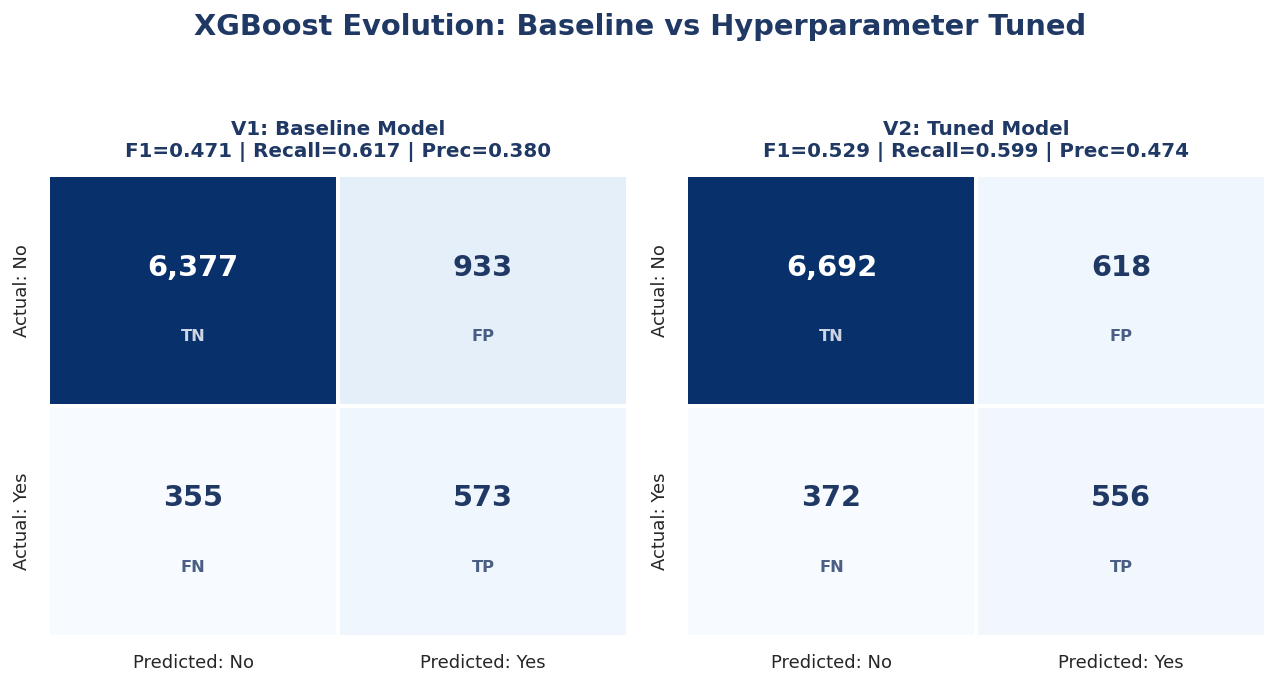

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
fig.suptitle('XGBoost Evolution: Baseline vs Hyperparameter Tuned', 
             fontsize=16, fontweight='bold', color=NAVY, y=1.05)

configs = [
    (v1_pred, 'V1: Baseline Model'),
    (v2_pred, 'V2: Tuned Model')
]

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for ax, (pred, title) in zip(axes, configs):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=False, ax=ax, cmap='Blues', cbar=False,
                linewidths=2, linecolor='white')
    
    ax.set_xticklabels(['Predicted: No', 'Predicted: Yes'], fontsize=10)
    ax.set_yticklabels(['Actual: No', 'Actual: Yes'], fontsize=10, va='center')
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            tc = 'white' if val > cm.max()*0.5 else NAVY
            
            ax.text(j+0.5, i+0.4, f"{val:,}", ha='center', va='center', 
                    fontsize=16, fontweight='bold', color=tc)
            ax.text(j+0.5, i+0.7, cell_labels[i][j], ha='center', va='center', 
                    fontsize=9, fontweight='bold', color=tc, alpha=0.8)
    
    f1  = f1_score(y_test, pred)
    rec = recall_score(y_test, pred)
    pre = precision_score(y_test, pred)
    
    ax.set_title(f'{title}\nF1={f1:.3f} | Recall={rec:.3f} | Prec={pre:.3f}', 
                 fontsize=11, fontweight='bold', color=NAVY, pad=10)

plt.tight_layout()
plt.savefig('xg_confusion_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## All Model Performance Charts

In [46]:

baseline_models = [
    ('Logistic Regression', lg_y_pred, lg_y_prob),
    ('Random Forest', rf_y_pred, rf_y_prob),
    ('XGBoost', v1_pred, v1_pred_proba),
]

tuned_models = [
    ('Logistic Regression', lg_y_pred_tuned, lg_y_prob_tuned),
    ('Random Forest', rf_y_pred_tuned, rf_y_prob_tuned),
    ('XGBoost', v2_pred, v2_pred_proba),
]

def make_perf_df(models):
    rows = []
    for name, pred, prob in models:
        rows.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'ROC-AUC': roc_auc_score(y_test, prob),
            'F1 (yes)': f1_score(y_test, pred),
            'Recall (yes)': recall_score(y_test, pred),
            'Precision (yes)': precision_score(y_test, pred),
        })
    df = pd.DataFrame(rows)
    df[['Accuracy', 'ROC-AUC', 'F1 (yes)', 'Recall (yes)', 'Precision (yes)']] = (
        df[['Accuracy', 'ROC-AUC', 'F1 (yes)', 'Recall (yes)', 'Precision (yes)']].round(4)
    )
    return df

print('Baseline model comparison')
display(make_perf_df(baseline_models))

print('\nTuned model comparison')
display(make_perf_df(tuned_models))

Baseline model comparison


,Model,Accuracy,ROC-AUC,F1 (yes),Recall (yes),Precision (yes)
0,Logistic Regression,0.8983,0.7969,0.2886,0.1832,0.6800
1,Random Forest,0.8946,0.7819,0.3636,0.2672,0.5688
2,XGBoost,0.8437,0.7954,0.4708,0.6175,0.3805



Tuned model comparison


,Model,Accuracy,ROC-AUC,F1 (yes),Recall (yes),Precision (yes)
0,Logistic Regression,0.8984,0.7968,0.2889,0.1832,0.6827
1,Random Forest,0.8853,0.8078,0.5258,0.5647,0.4920
2,XGBoost,0.8798,0.8201,0.5290,0.5991,0.4736


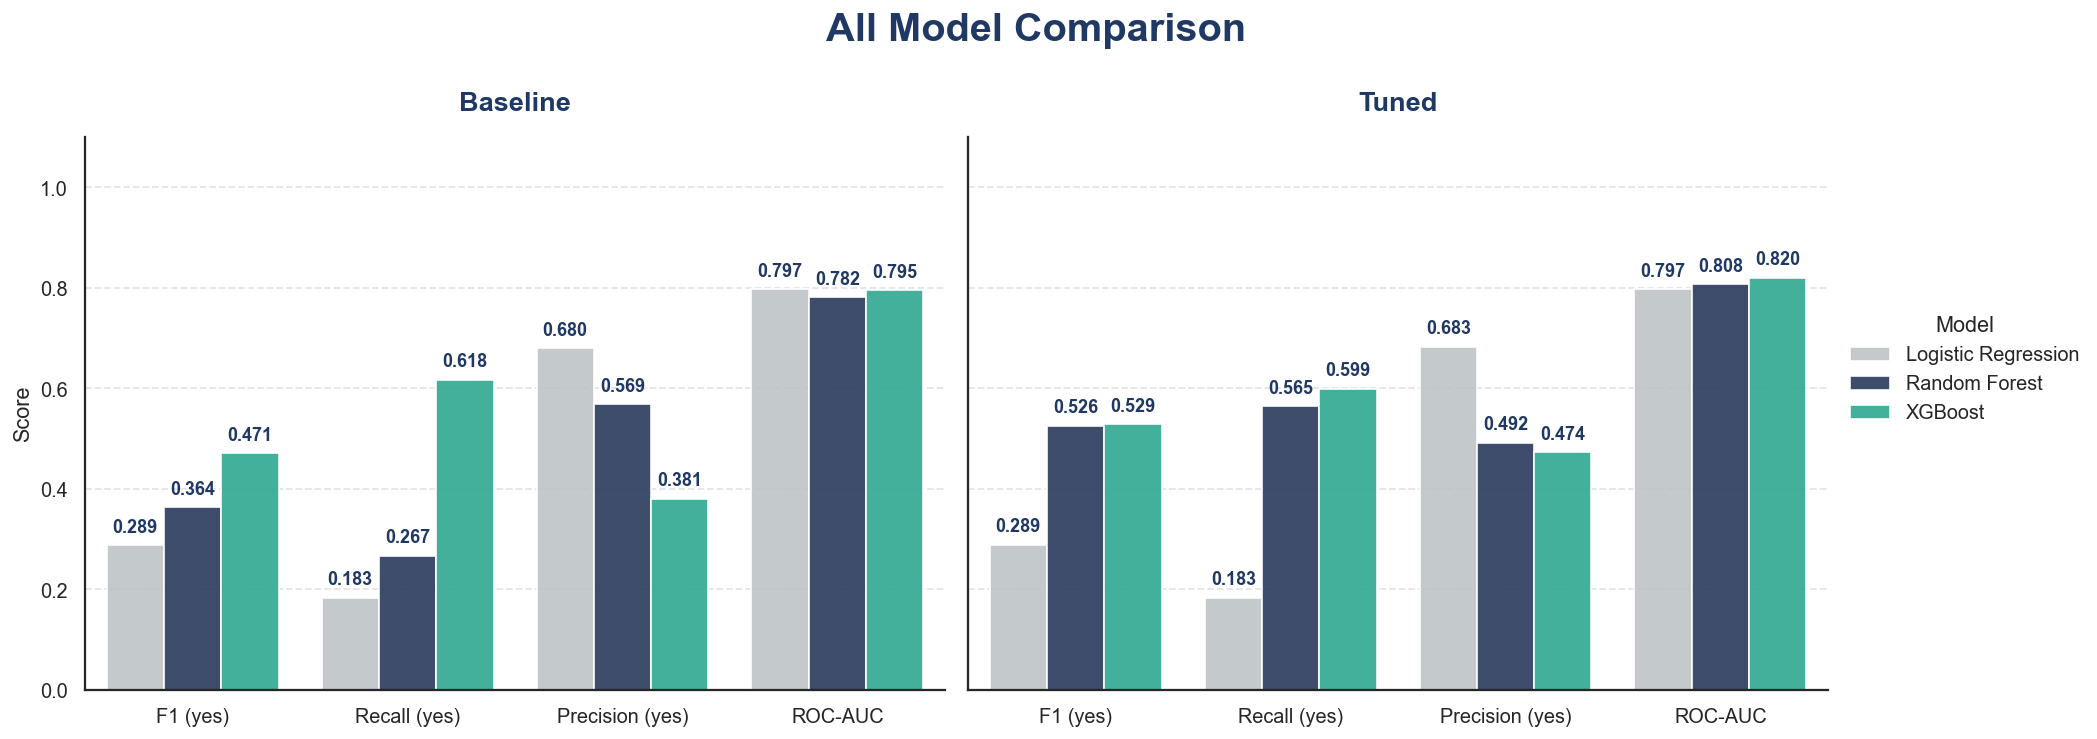

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

df_base = make_perf_df(baseline_models)
df_tuned = make_perf_df(tuned_models)
df_base['Stage'] = 'Baseline'
df_tuned['Stage'] = 'Tuned'
df_visual = pd.concat([df_base, df_tuned])

metrics_to_show = ['F1 (yes)', 'Recall (yes)', 'Precision (yes)', 'ROC-AUC']
df_melted = df_visual.melt(id_vars=['Model', 'Stage'], value_vars=metrics_to_show, 
                           var_name='Metric', value_name='Score')
custom_palette = {
    'Logistic Regression': GRAY,
    'Random Forest': NAVY,
    'XGBoost': TEAL
}
sns.set_theme(style="white", rc={'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.5})
g = sns.catplot(
    data=df_melted, kind="bar",
    x="Metric", y="Score", hue="Model", col="Stage",
    palette=custom_palette, alpha=0.9, height=6, aspect=1.2,
    edgecolor="white", linewidth=1
)

for ax in g.axes.flat:
    ax.set_title(ax.get_title().replace('Stage = ', ''), fontsize=15, fontweight='bold', color=NAVY, pad=15)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('') 
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.annotate(f'{height:.3f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontsize=10, fontweight='bold', color=NAVY)

plt.subplots_adjust(top=0.82)
g.fig.suptitle('All Model Comparison', 
               fontsize=22, fontweight='bold', color=NAVY)

plt.savefig('all_model_perf_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

**Key Justifications:**

- Highest F1-Score: XGBoost achieved the highest F1-Score among all candidates, indicating the best overall ability to distinguish between potential subscribers and non-subscribers.

- Optimal Balance for Business: While Logistic Regression has the highest Precision, its Recall is extremely low (18%). XGBoost offers a much better sweet spot by capturing 59% of actual subscribers (Recall) while maintaining a Precision.

**Conclusion**
- After a comprehensive evaluation, **XGBoost** is selected as the final production model. It demonstrates the strongest performance in balancing the trade-off between precision and recall, ensuring maximum customer acquisition for the bank's marketing campaign.

## XGBoost SHAP Analysis (Feature Importance)

In [48]:
# Use 500-row sample for speed
np.random.seed(42)

# 500 random samples from the test set)
sample_idx    = np.random.choice(len(X_test), size=500, replace=False) # sample index
X_test_sample = X_test.iloc[sample_idx] 

# XGBoost is tree-based
explainer   = shap.TreeExplainer(v2_model)
shap_values = explainer.shap_values(X_test_sample) #calculate SHAP values for 500 samples

# feature importance 
mean_shap = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('\nFeatures by SHAP importance (High to Low):')
print(mean_shap.to_string(index=False))


Features by SHAP importance (High to Low):
          feature  importance
       macro_eco1    0.617438
    cons.conf.idx    0.197238
contact_telephone    0.167544
 poutcome_success    0.107176
        month_may    0.097443
              age    0.057244
         campaign    0.047309
         previous    0.033185
  day_of_week_mon    0.032764
        month_oct    0.024695
  default_unknown    0.022821
        education    0.017352
  day_of_week_wed    0.016708
   marital_single    0.012917
        month_jun    0.012387
      housing_yes    0.011757
  day_of_week_thu    0.010144
      job_retired    0.009174
         loan_yes    0.006635
  job_blue-collar    0.006611
  day_of_week_tue    0.005298
   job_management    0.004605
   job_technician    0.004330
  marital_married    0.004267
 job_entrepreneur    0.004206
     job_services    0.003718
        month_aug    0.003272
    job_housemaid    0.003082
        month_jul    0.002550
      job_student    0.002431
   job_unemployed    0.001

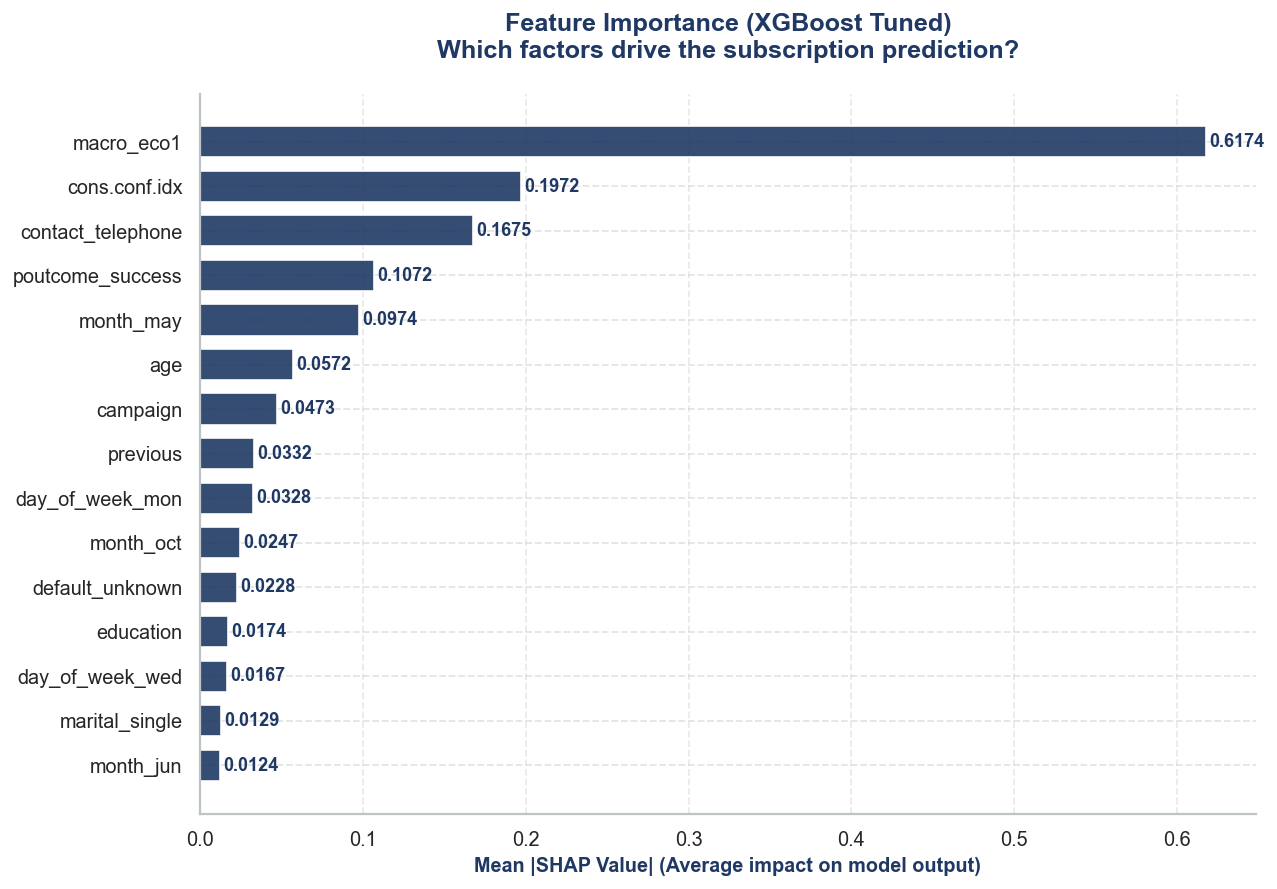

In [49]:
top15 = mean_shap.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 7), dpi=130)

ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        color=NAVY, edgecolor='white', height=0.7, alpha=0.9)

for i, val in enumerate(top15['importance'][::-1]):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', 
            fontsize=10, fontweight='bold', color=NAVY)

ax.set_xlabel('Mean |SHAP Value| (Average impact on model output)', 
              fontsize=11, fontweight='bold', color=NAVY)
ax.set_title('Feature Importance (XGBoost Tuned)\n'
             'Which factors drive the subscription prediction?',
             fontsize=14, fontweight='bold', color=NAVY, pad=20)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color(GRAY)
ax.spines['bottom'].set_color(GRAY)

plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_40484\1647085823.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample,


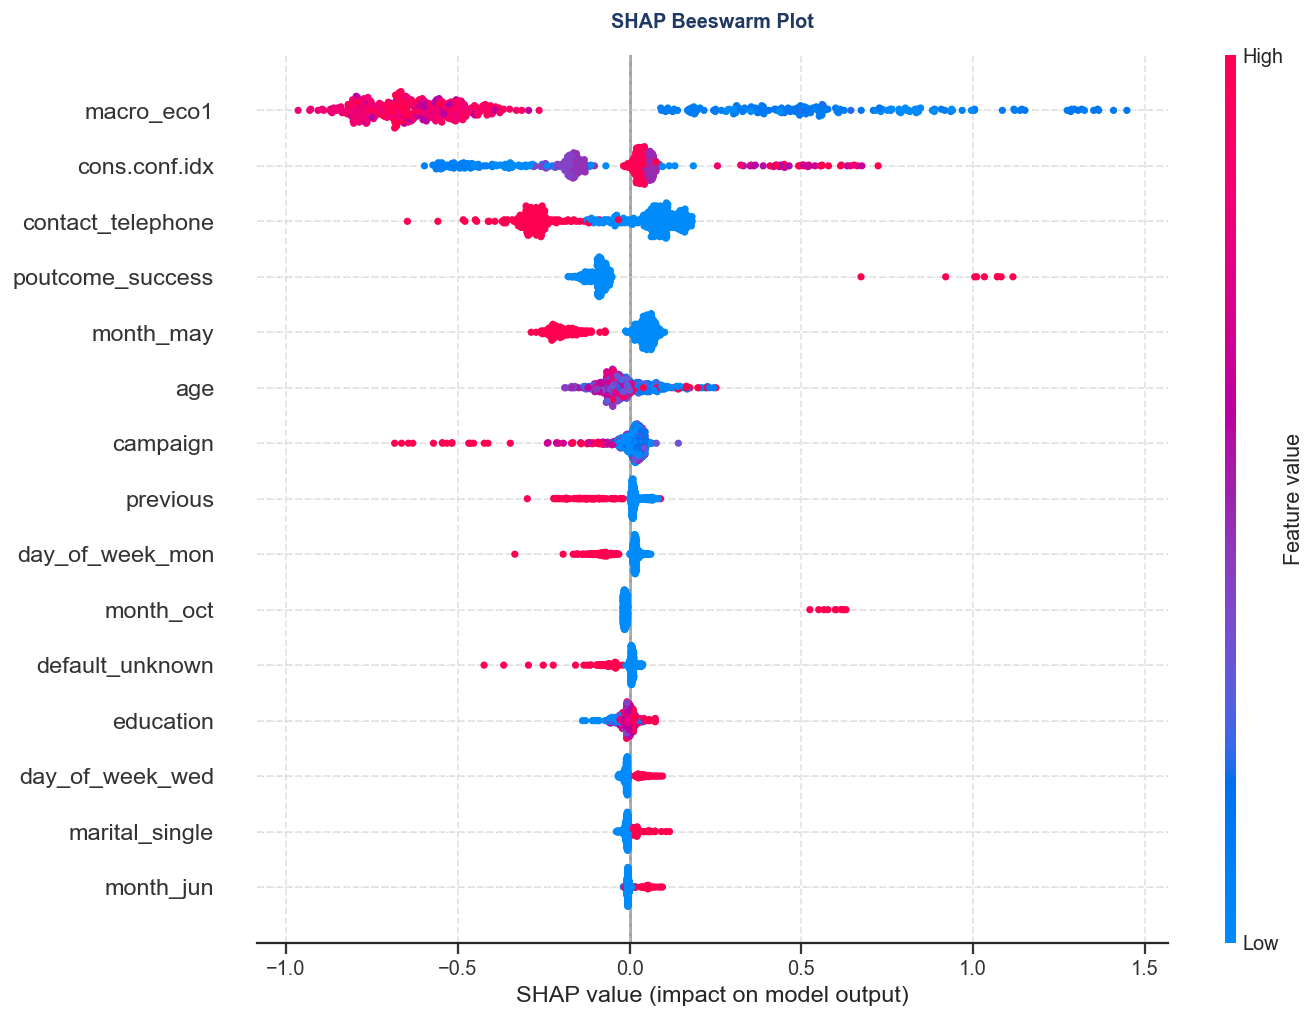

In [50]:
# SHAP Beeswarm

fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=FEATURE_NAMES,
                  max_display=15, show=False, plot_size=None)
plt.title('SHAP Beeswarm Plot',
          fontsize=11, fontweight='bold', color=NAVY, pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

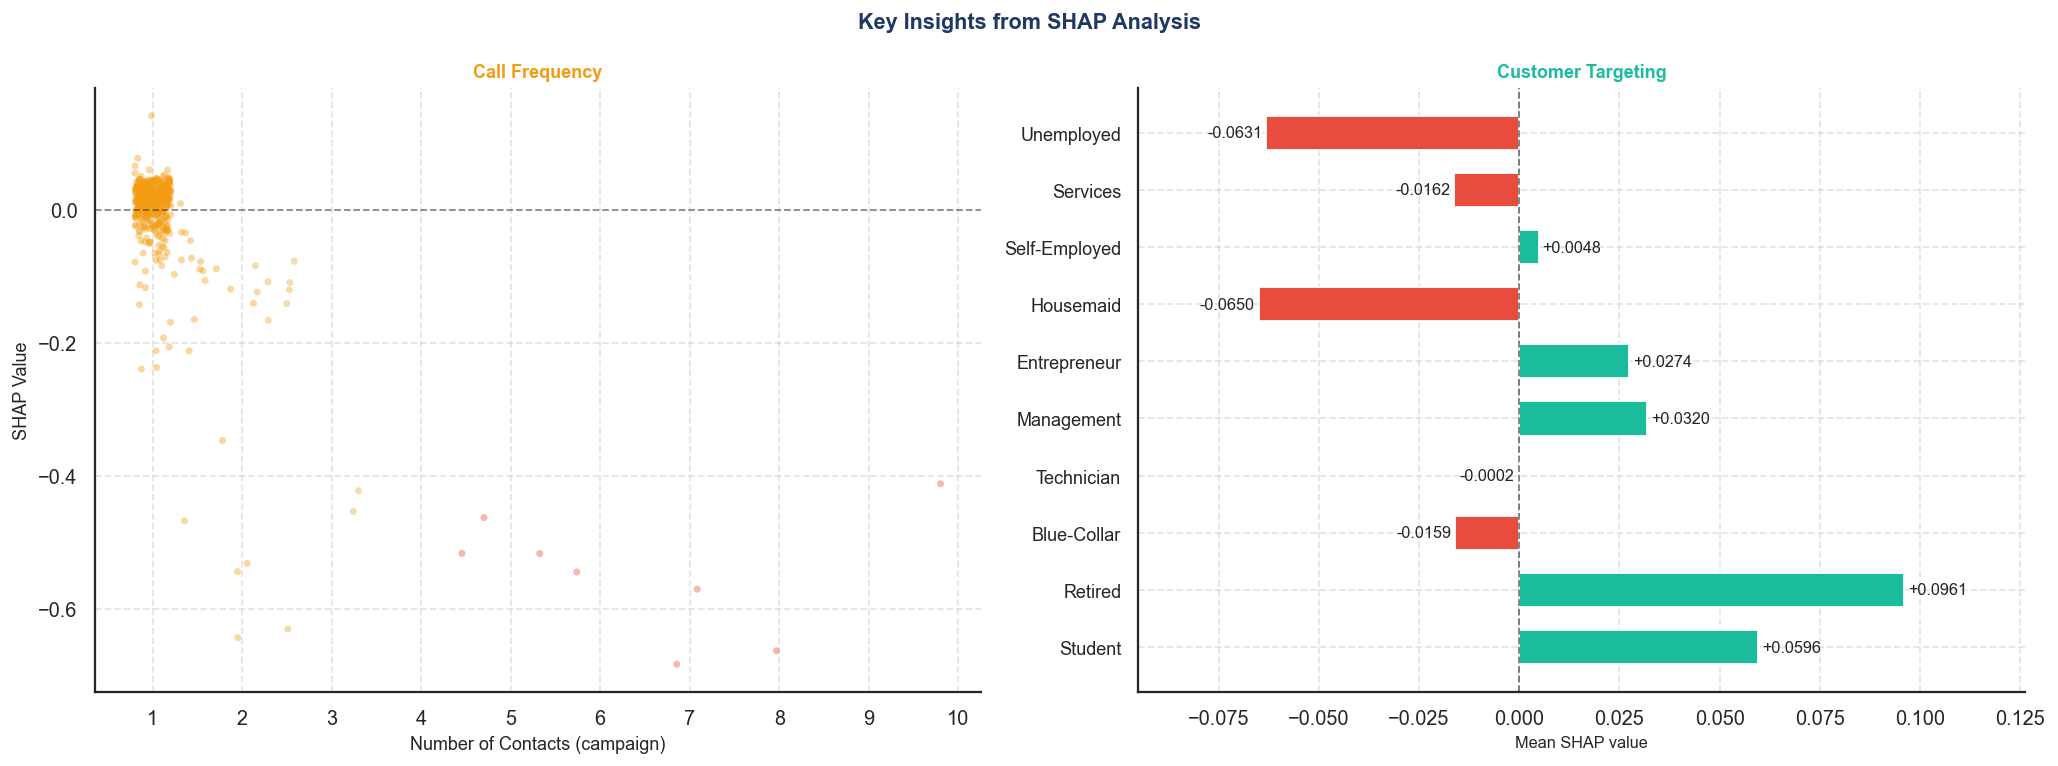

In [51]:
# SHAP Dependence Plots 
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 
fig.suptitle(
    'Key Insights from SHAP Analysis',
    fontsize=12, fontweight='bold', color=NAVY
)

camp_vals = X_test_sample['campaign'].values
camp_shap = shap_values[:, FEATURE_NAMES.index('campaign')]
camp_clip = np.clip(camp_vals, 1, 10) 

for c_val in sorted(set(camp_clip)):
    mask = camp_clip == c_val
    color_c = AMBER if c_val <= 2 else RED if c_val >= 4 else '#E8A838'
    axes[0].scatter(
        np.full(mask.sum(), c_val) + np.random.uniform(-0.2, 0.2, mask.sum()),
        camp_shap[mask], alpha=0.4, s=15, color=color_c, edgecolors='none'
    )
axes[0].axhline(y=0, color='black', lw=1, linestyle='--', alpha=0.4)
axes[0].set_xlabel('Number of Contacts (campaign)', fontsize=10)
axes[0].set_ylabel('SHAP Value', fontsize=10)
axes[0].set_title('Call Frequency', 
                  fontsize=10, fontweight='bold', color=AMBER)
axes[0].set_xticks(range(1, 11))
axes[0].spines[['top', 'right']].set_visible(False)

job_features = [f for f in ['job_student', 'job_retired', 'job_blue-collar',
                             'job_technician', 'job_management',
                             'job_entrepreneur', 'job_housemaid', 'job_self-employed','job_services','job_unemployed'] if f in FEATURE_NAMES]
job_shap_means, job_labels, job_colors_bar = [], [], []
for feat in job_features:
    idx  = FEATURE_NAMES.index(feat)
    mask = X_test_sample[feat].values == 1
    if mask.sum() > 0:
        mean_s = shap_values[:, idx][mask].mean()
        job_shap_means.append(mean_s)
        job_labels.append(feat.replace('job_', '').title())
        job_colors_bar.append(TEAL if mean_s > 0 else RED)

y_pos = range(len(job_labels))
axes[1].barh(list(y_pos), job_shap_means, color=job_colors_bar,
             edgecolor='white', height=0.6)
axes[1].axvline(x=0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(job_labels, fontsize=10)
axes[1].set_xlabel('Mean SHAP value', fontsize=9)
axes[1].set_title('Customer Targeting',
                  fontsize=10, fontweight='bold', color=TEAL)

for val, bar in zip(job_shap_means, axes[1].patches):
    axes[1].text(val + (0.001 if val >= 0 else -0.001),
                  bar.get_y() + bar.get_height()/2,
                  f'{val:+.4f}', va='center', fontsize=9,
                  ha='left' if val >= 0 else 'right')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_xlim(min(job_shap_means) - 0.03, max(job_shap_means) + 0.03)

plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.savefig('shap_insights.png', bbox_inches='tight', dpi=150)
plt.show()

## Final Business Output — Ranked Contact List

"Who should we call?" 
clients ranked by subscription probability with business filters applied.

In [54]:
ranked = X_test.copy()
ranked['actual_subscribed'] = y_test.values
ranked['subscribe_prob'] = v2_pred_proba

ranked_filtered = ranked.loc[ranked['campaign'] < 3].copy()
ranked_filtered.sort_values('subscribe_prob', ascending=False, inplace=True)
ranked_filtered.reset_index(drop=True, inplace=True)
ranked_filtered.index += 1

total_clients = len(ranked)
filtered_clients = len(ranked_filtered)
total_real_subs = ranked['actual_subscribed'].sum()
random_rate = total_real_subs / total_clients

job_cols = [col for col in ranked_filtered.columns if col.startswith('job_')]

def decode_job(row):
    active = [col for col in job_cols if row[col] in (1, True)]
    if not active:
        return 'Other'
    return active[0].replace('job_', '').replace('-', ' ').title()

ranked_filtered['Job'] = ranked_filtered.apply(decode_job, axis=1) if job_cols else 'Other'
ranked_filtered['Economic Cond.'] = ranked_filtered['macro_eco1']
ranked_filtered['No. of Calls'] = ranked_filtered['campaign'].apply(
    lambda x: int(round(x)) if abs(x) < 10 else 1
)
ranked_filtered['Likelihood'] = ranked_filtered['subscribe_prob'].map(
    lambda x: f'{x*100:.1f}%'
)
ranked_filtered['Subscribe?'] = ranked_filtered['actual_subscribed'].map(
    lambda x: 'Yes' if x == 1 else 'No'
)

display_cols = ['Likelihood', 'Job', 'Economic Cond.', 'Subscribe?']
display_df = ranked_filtered[display_cols].head(20).copy()
display_df.index.name = 'Rank'

separator = '=' * 65
print(separator)
print('FINAL RANKED CONTACT LIST — Top 20 Clients to Call')
print(separator)
print(f'Total clients in test set          : {total_clients:,}')
print(f'After "≤2 calls" filter (Insight 2): {filtered_clients:,}')
print(f'Total real subscribers             : {total_real_subs:,}')
print(f'Random success rate (no model)     : {random_rate*100:.1f}%\n')
print(display_df.to_string())

print(f'\n{separator}')
print('BUSINESS IMPACT: How many subscribers do we capture?')
print(separator)
print(f'{"Call Top":<12} {"Clients":<10} {"Subscribers":<14} '
      f'{"Capture Rate":<15} {"Success Rate":<15} {"Lift vs Random"}')
print('-' * 75)

for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]:
    k = max(1, int(pct * filtered_clients))
    top_k = ranked_filtered.head(k)
    subs_found = int(top_k['actual_subscribed'].sum())
    capture = subs_found / total_real_subs
    success = subs_found / k
    lift = success / random_rate
    print(
        f'  Top {pct*100:.0f}%{"":>4} {k:<10,} {subs_found:<14,} '
        f'{capture*100:<13.1f}%  {success*100:<13.1f}%  ×{lift:.1f}'
    )


FINAL RANKED CONTACT LIST — Top 20 Clients to Call
Total clients in test set          : 8,238
After "≤2 calls" filter (Insight 2): 8,056
Total real subscribers             : 928
Random success rate (no model)     : 11.3%

     Likelihood         Job  Economic Cond. Subscribe?
Rank                                                  
1         92.0%     Retired       -2.188797        Yes
2         91.8%     Retired       -2.789067         No
3         91.7%       Other       -2.310252        Yes
4         91.6%     Retired       -2.178690        Yes
5         91.6%       Other       -2.407228        Yes
6         91.6%     Retired       -2.309641        Yes
7         91.5%       Other       -2.184214        Yes
8         91.5%  Unemployed       -2.405700        Yes
9         91.4%       Other       -2.311169        Yes
10        91.4%       Other       -2.176552        Yes
11        91.4%  Technician       -2.311474        Yes
12        91.3%  Management       -2.405089        Yes
13      

**Optimization Strategy:**

- The model (XGBoost) was integrated with Business Insight 2, focusing only on clients with <3 prior contacts to maximize efficiency. This filtered the target list to 8,056 high-potential leads from the initial test set.

**Key Findings & Strategic Gains:**
- Significant Lift: By targeting the Top 10% of the ranked list (805 clients), the bank can capture 45.6% of all actual subscribers.
- Superior Accuracy: The success rate in the Top 10% is 52.7%, which is 4.7 times higher than the random success rate (11.3%).
- Resource Efficiency: To capture approximately 80% of total subscribers, the bank only needs to call 40% of the filtered list, saving 60% of marketing resources and time.

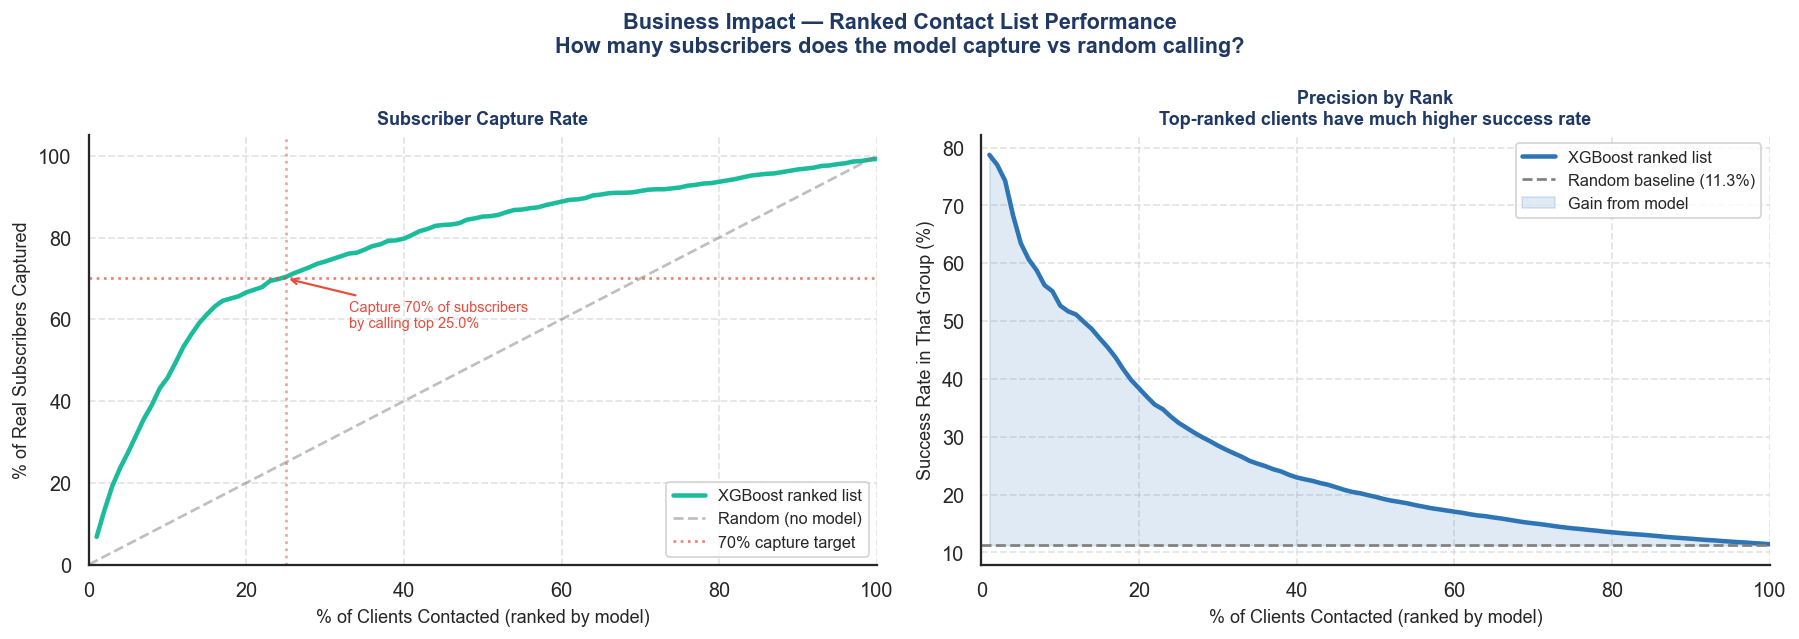

In [53]:
pcts      = np.arange(0.01, 1.01, 0.01)
captures  = []
successes = []

for pct in pcts:
    k    = max(1, int(pct * filtered_clients))
    subs = ranked_filtered.head(k)['actual_subscribed'].sum()
    captures.append(subs / total_real_subs)
    successes.append(subs / k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Business Impact — Ranked Contact List Performance\n'
             'How many subscribers does the model capture vs random calling?',
             fontsize=12, fontweight='bold', color=NAVY)

# Left: Capture Rate
axes[0].plot(pcts*100, [c*100 for c in captures],
             color=TEAL, lw=2.5, label='XGBoost ranked list')
axes[0].plot([0, 100], [0, 100], '--', color='gray',
             alpha=0.5, lw=1.5, label='Random (no model)')
axes[0].axhline(y=70, color=RED, linestyle=':', alpha=0.7, label='70% capture target')

idx_70 = next((i for i, c in enumerate(captures) if c >= 0.70), None)
if idx_70:
    axes[0].axvline(x=pcts[idx_70]*100, color=RED, linestyle=':', alpha=0.5)
    axes[0].annotate(
        f'Capture 70% of subscribers\nby calling top {pcts[idx_70]*100:.1f}%',
        xy=(pcts[idx_70]*100, 70),
        xytext=(pcts[idx_70]*100 + 8, 58),
        fontsize=8, color=RED,
        arrowprops=dict(arrowstyle='->', color=RED, lw=1.2)
    )

axes[0].set_xlabel('% of Clients Contacted (ranked by model)', fontsize=10)
axes[0].set_ylabel('% of Real Subscribers Captured', fontsize=10)
axes[0].set_title('Subscriber Capture Rate',
                  fontweight='bold', color=NAVY, fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 105)
axes[0].spines[['top', 'right']].set_visible(False)

# Right: Success Rate
axes[1].plot(pcts*100, [s*100 for s in successes],
             color=BLUE, lw=2.5, label='XGBoost ranked list')
axes[1].axhline(y=random_rate*100, color='gray', linestyle='--', lw=1.5,
                label=f'Random baseline ({random_rate*100:.1f}%)')
axes[1].fill_between(
    pcts*100, [s*100 for s in successes], random_rate*100,
    where=[s > random_rate for s in successes],
    alpha=0.15, color=BLUE, label='Gain from model'
)
axes[1].set_xlabel('% of Clients Contacted (ranked by model)', fontsize=10)
axes[1].set_ylabel('Success Rate in That Group (%)', fontsize=10)
axes[1].set_title('Precision by Rank\nTop-ranked clients have much higher success rate',
                  fontweight='bold', color=NAVY, fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 100)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('gain_lift_chart.png', bbox_inches='tight', dpi=150)
plt.show()